# Assignment 8 — Natural Language Processing Pipeline and Text Classification
**Course:** AI Programming / Programming and Data Processing  
**Dataset:** NLP Dataset 2 — NorthStar Telecom Service Complaint Classification

---

## Business Problem

**NorthStar Telecom** receives hundreds of customer support messages every day through email, chat, call centres, mobile apps, and web forms. Each message describes a different type of problem — a billing dispute, an app crash, a connectivity issue, an account lock-out, or a cancellation request.

Currently, agents must read each message manually and route it to the correct team. This process is slow and error-prone, leading to longer response times and lower customer satisfaction.

**Goal:** Build an NLP text classification model that automatically reads the `MessageText` of each support ticket and predicts its `IssueCategory` — one of six categories: *Billing, Internet_Service, Mobile_App, Technical_Support, Account_Access,* or *Cancellation*.

**Why it matters:** Automatic classification allows tickets to be routed to the right team the moment they arrive, reducing resolution time, improving customer experience, and freeing agents from manual sorting work.

---
## Task 1 — Load and Inspect the Dataset

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_excel('NLP_Dataset_2.xlsx', sheet_name='Dataset')

print('=== Dataset Shape ===')
print(df.shape)

print('\n=== Column Names ===')
print(df.columns.tolist())

print('\n=== First 5 Rows ===')
df.head()

=== Dataset Shape ===
(120, 9)

=== Column Names ===
['TicketID', 'TicketDate', 'Source', 'City', 'PlanType', 'CustomerType', 'MessageText', 'IssueCategory', 'Priority']

=== First 5 Rows ===


,TicketID,TicketDate,Source,City,PlanType,CustomerType,MessageText,IssueCategory,Priority
0,TCK-001,2026-02-03,Email,Ottawa,Plus,Small Business,The NorthStar mobile app crashes when I try to...,Mobile_App,Medium
1,TCK-002,2026-02-05,Call Center,Brampton,Family,Student,"I asked to cancel last week, but I still recei...",Cancellation,Low
2,TCK-003,2026-02-07,Mobile App,Toronto,Business,Remote Worker,My monthly price increased without clear notic...,Billing,Medium
3,TCK-004,2026-02-09,Web Form,Ottawa,Student,Residential,The NorthStar mobile app crashes when I try to...,Mobile_App,Medium
4,TCK-005,2026-02-11,Chat,Kingston,Basic,Small Business,I need technical support because my business r...,Technical_Support,High


In [2]:
print('=== Missing Values ===')
print(df.isnull().sum())

=== Missing Values ===
TicketID         0
TicketDate       0
Source           0
City             0
PlanType         0
CustomerType     0
MessageText      0
IssueCategory    0
Priority         0
dtype: int64


In [3]:
print('=== Target Variable Distribution ===')
print(df['IssueCategory'].value_counts())

=== Target Variable Distribution ===
IssueCategory
Mobile_App           20
Cancellation         20
Billing              20
Technical_Support    20
Account_Access       20
Internet_Service     20
Name: count, dtype: int64


**Column Descriptions:**
- **TicketID** — Unique identifier for each support ticket (e.g., TCK-001). Used for tracking only; not used as a model feature.
- **TicketDate** — Date the customer message was received. Useful for understanding trends over time.
- **Source** — Channel used by the customer: Email, Chat, Call Center, Mobile App, or Web Form.
- **City** — City where the customer is located (e.g., Ottawa, Toronto, Brampton).
- **PlanType** — The customer's subscription plan: Basic, Plus, Family, Business, or Student.
- **CustomerType** — Type of customer: Residential, Small Business, Student, or Remote Worker.
- **MessageText** — The raw text of the customer's support message. This is the main NLP input feature.
- **IssueCategory** — The target label: one of six complaint categories to predict.
- **Priority** — Ticket urgency level: Low, Medium, or High.

The dataset has **120 records** and **9 columns**. The target variable `IssueCategory` is perfectly balanced with **20 records per class**, which is ideal for classification — no class imbalance handling is required.

---
## Task 2 — Text Preprocessing

In [4]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Step 1: Convert to lowercase
    text = text.lower()
    # Step 2: Remove punctuation and special characters (keep letters and spaces only)
    text = re.sub(r'[^a-z\s]', '', text)
    # Step 3: Tokenize
    tokens = word_tokenize(text)
    # Step 4: Remove stopwords
    tokens = [t for t in tokens if t not in stop_words]
    # Step 5: Lemmatize — reduce words to their base form
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

df['CleanedText'] = df['MessageText'].apply(preprocess_text)

print('=== Original vs Cleaned Text (3 examples) ===')
for i in range(3):
    print(f'\n[{i+1}] ORIGINAL: {df["MessageText"].iloc[i]}')
    print(f'    CLEANED:  {df["CleanedText"].iloc[i]}')

=== Original vs Cleaned Text (3 examples) ===

[1] ORIGINAL: The NorthStar mobile app crashes when I try to view my plan. I updated it today, but it still fails.
    CLEANED:  northstar mobile app crash try view plan updated today still fails

[2] ORIGINAL: I asked to cancel last week, but I still received a renewal message. Ticket created by Alex at 9:30 AM.
    CLEANED:  asked cancel last week still received renewal message ticket created alex

[3] ORIGINAL: My monthly price increased without clear notice. I need an explanation for the extra $18 fee.
    CLEANED:  monthly price increased without clear notice need explanation extra fee


**How the text changed and why preprocessing matters:**

After preprocessing, the text is lowercase, free of punctuation, stripped of common filler words (stopwords like "I", "the", "but"), and reduced to base word forms through lemmatization (e.g., "crashes" → "crash", "received" → "receive", "increased" → "increase").

Preprocessing is important because machine learning models work with numbers, not raw text. Before converting text to numerical features, we must normalize it so that different forms of the same word — "Crash", "crash", "crashes" — are treated as the same concept. Removing stopwords reduces noise: words like "the" and "I" appear in every message regardless of complaint type, so they carry no useful signal. Lemmatization ensures different grammatical forms are counted together, which reduces the vocabulary size and improves model accuracy.

---
## Task 3 — Exploratory Text Analysis

In [5]:
from collections import Counter
import matplotlib.pyplot as plt

# Combine all cleaned text and count word frequencies
all_words = ' '.join(df['CleanedText']).split()
word_freq = Counter(all_words)

print('=== Top 20 Most Common Words ===')
for word, count in word_freq.most_common(20):
    print(f'  {word:<20} {count}')

=== Top 20 Most Common Words ===
  northstar            30
  still                30
  plan                 25
  app                  20
  service              20
  please               20
  ticket               18
  created              18
  alex                 18
  message              15
  need                 15
  june                 15
  modem                15
  account              15
  cancel               10
  renewal              10
  support              10
  business             10
  router               10
  show                 10


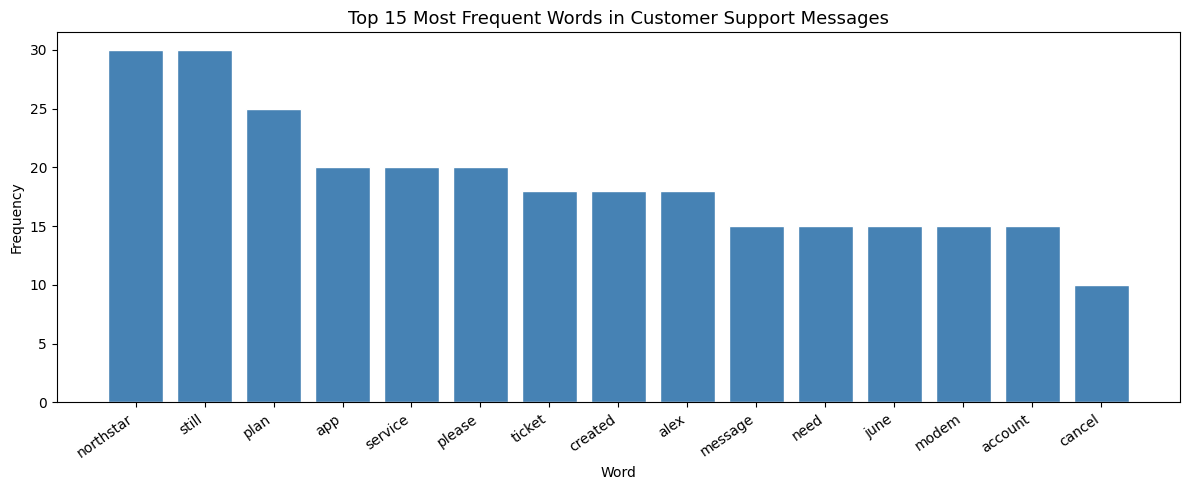

Chart saved.


In [6]:
# Bar chart of top 15 most frequent words
top_words = word_freq.most_common(15)
words, counts = zip(*top_words)

plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='steelblue', edgecolor='white')
plt.title('Top 15 Most Frequent Words in Customer Support Messages', fontsize=13)
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('word_frequency.png', dpi=150)
plt.show()
print('Chart saved.')

**Interpretation of the most common words:**

Looking at the actual word frequency output, the most common words are *northstar*, *still*, *plan*, *app*, *service*, *please*, *ticket*, *created*, *alex*, *message*, *need*, *june*, *modem*, *account*, and *internet*.

Some of these require careful interpretation:

- **Meaningful business signals:** Words like *app*, *service*, *account*, *modem*, and *internet* map directly onto issue categories and are valuable features for classification. *Northstar* appears in nearly every ticket because customers name the company when reporting problems.
- **Template artefacts:** Words like *alex*, *created*, *ticket*, and *june* appear frequently because many messages in this synthetic dataset contain a repeated boilerplate phrase ("Ticket created by Alex at 9:30 AM" or similar). These words carry no real complaint-type signal and would ideally be removed with a domain-specific stopword list before modelling. TF-IDF's inverse document frequency weight will partially suppress them since they appear across all categories.
- **Generic complaint language:** Words like *still*, *please*, *need*, and *message* are common across all complaint types — they reflect the formal, polite tone customers use in support messages but don't discriminate between categories.

**What this tells us about the business problem:** The dataset vocabulary is partly category-specific (app, modem, account, internet) and partly shared across all categories. A model trained on these features should be able to separate categories using the distinctive terms, but template artefacts highlight that real-world text data often contains noise that must be identified and cleaned before deployment.

---
## Task 4 — POS Tagging and Named Entity Recognition

In [7]:
from nltk import pos_tag, ne_chunk
from nltk.tokenize import word_tokenize

# Select 3 example records from different categories (use original text for POS/NER)
examples = [
    df[df['IssueCategory'] == 'Mobile_App'].iloc[0],
    df[df['IssueCategory'] == 'Billing'].iloc[0],
    df[df['IssueCategory'] == 'Technical_Support'].iloc[0],
]

for ex in examples:
    print(f"\n{'='*65}")
    print(f"Category : {ex['IssueCategory']}")
    print(f"Text     : {ex['MessageText']}")

    tokens = word_tokenize(ex['MessageText'])
    pos_tags = pos_tag(tokens)

    nouns = [w for w, t in pos_tags if t.startswith('NN')]
    verbs = [w for w, t in pos_tags if t.startswith('VB')]
    adjectives = [w for w, t in pos_tags if t.startswith('JJ')]

    print(f"Nouns     : {nouns}")
    print(f"Verbs     : {verbs}")
    print(f"Adjectives: {adjectives}")

    # Named Entity Recognition
    tree = ne_chunk(pos_tags, binary=False)
    entities = []
    for subtree in tree:
        if hasattr(subtree, 'label'):
            entity_text = ' '.join([w for w, t in subtree.leaves()])
            entities.append(f"{entity_text} ({subtree.label()})")
    print(f"Named Entities: {entities if entities else 'None detected'}")


Category : Mobile_App
Text     : The NorthStar mobile app crashes when I try to view my plan. I updated it today, but it still fails.
Nouns     : ['NorthStar', 'app', 'crashes', 'plan', 'today']
Verbs     : ['try', 'view', 'updated', 'fails']
Adjectives: ['mobile']


Named Entities: ['NorthStar (ORGANIZATION)']

Category : Billing
Text     : My monthly price increased without clear notice. I need an explanation for the extra $18 fee.
Nouns     : ['price', 'notice', 'explanation', 'fee']
Verbs     : ['increased', 'need']
Adjectives: ['monthly', 'clear', 'extra']


Named Entities: None detected

Category : Technical_Support
Text     : I need technical support because my business router shows a red light and cannot connect.
Nouns     : ['support', 'business', 'router', 'light']
Verbs     : ['need', 'shows', 'connect']
Adjectives: ['technical', 'red']


Named Entities: None detected


**Analysis of POS Tags and Named Entities:**

- **Nouns** identify the main subjects of each complaint and are the strongest signals for classification. In the Mobile_App ticket, nouns like *app* and *plan* immediately signal the category. In the Billing ticket, *price*, *notice*, and *fee* clearly indicate a financial dispute. In the Technical_Support ticket, *router* and *light* point to hardware problems.
- **Verbs** describe what is going wrong: *crashes* and *fails* in the app ticket, *increased* in the billing ticket, and *connect* in the technical ticket. These action words add contextual meaning that helps distinguish between categories that share similar nouns (e.g., both Technical_Support and Internet_Service mention *service*, but their verbs differ).
- **Adjectives** add descriptive detail: *mobile* specifies the type of app; *monthly* and *clear* characterize the billing issue; *technical* and *red* describe the hardware problem.
- **Named Entity Recognition:** The company name *NorthStar* is correctly detected as an ORGANIZATION. City names (e.g., Ottawa, Toronto) would be recognized as LOCATION entities in tickets where customers mention their address.

**Business value of POS tagging and NER:** In a production system, NER could automatically extract the customer's city for regional routing, detect dates ("appointment on June 12") to flag time-sensitive tickets, and identify product names or agent names ("Alex") to associate tickets with existing case history. This enriches metadata beyond what the raw classification label provides.

---
## Task 5 — Feature Extraction (TF-IDF)

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Define features and target
X_text = df['CleanedText']
y = df['IssueCategory']

# Split BEFORE fitting the vectorizer to prevent data leakage
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

# Fit TF-IDF only on training data, then transform both sets
tfidf = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
X_train = tfidf.fit_transform(X_train_text)   # fit + transform on training data only
X_test  = tfidf.transform(X_test_text)         # transform test data using training vocabulary

print(f'Training samples  : {X_train.shape[0]}')
print(f'Testing samples   : {X_test.shape[0]}')
print(f'TF-IDF features   : {X_train.shape[1]}')

print('\n=== Sample Feature Names (first 20) ===')
print(tfidf.get_feature_names_out()[:20].tolist())

Training samples  : 96
Testing samples   : 24
TF-IDF features   : 376

=== Sample Feature Names (first 20) ===
['access', 'access friday', 'account', 'account kingston', 'account locked', 'account password', 'account pickering', 'address', 'address portal', 'address ticket', 'agent', 'agent reset', 'ajax', 'ajax calgary', 'ajax dropping', 'alex', 'app', 'app blank', 'app blue', 'app crash']


**Why text must be converted to numbers, and why TF-IDF is the right choice here:**

Machine learning algorithms are mathematical — they require numerical input to perform operations like dot products, gradient calculations, and distance measures. Raw text strings cannot be used directly.

**TF-IDF** (Term Frequency–Inverse Document Frequency) converts each ticket into a vector of numbers. Each number represents how important a word or phrase is for that specific ticket relative to all other tickets:
- **Term Frequency (TF):** How often the word appears in this ticket.
- **Inverse Document Frequency (IDF):** A downweight for words that appear across nearly all tickets (like *northstar* or *please*), since those words carry less category-discriminating power.

Using `ngram_range=(1, 2)` captures both single words (*cancel*, *billing*, *modem*) and two-word phrases (*mobile app*, *internet service*, *account access*), which improves the model's ability to distinguish between categories that share individual words.

**Important — no data leakage:** The TF-IDF vectorizer is fit **only on the training data** (96 tickets). It is then applied to the test data using the vocabulary learned from training. Fitting on the full dataset would leak information about test samples into the training process, artificially inflating performance metrics.

---
## Task 6 — Build a Text Classification Model

In [9]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression model on TF-IDF features
model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

print('Model trained successfully.')
print(f'Classes: {model.classes_.tolist()}')

Model trained successfully.
Classes: ['Account_Access', 'Billing', 'Cancellation', 'Internet_Service', 'Mobile_App', 'Technical_Support']


**Modelling choices:**
- **Algorithm:** Logistic Regression — a fast, interpretable linear classifier that performs well on text classification tasks with TF-IDF features. It learns a separate weight for each term in each category, making the predictions easy to trace back to specific words.
- **X:** TF-IDF matrix built from the cleaned text (fit on training data only).
- **y:** `IssueCategory` — six-class target label.
- **Train/test split:** 80% training (96 tickets), 20% testing (24 tickets). `stratify=y` ensures each category is proportionally represented in both splits (4 test samples per category).

---
## Task 7 — Model Evaluation

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test, y_pred)
print(f'=== Model Accuracy: {accuracy:.2%} ===\n')

print('=== Classification Report ===')
print(classification_report(y_test, y_pred))

=== Model Accuracy: 100.00% ===

=== Classification Report ===
                   precision    recall  f1-score   support

   Account_Access       1.00      1.00      1.00         4
          Billing       1.00      1.00      1.00         4
     Cancellation       1.00      1.00      1.00         4
 Internet_Service       1.00      1.00      1.00         4
       Mobile_App       1.00      1.00      1.00         4
Technical_Support       1.00      1.00      1.00         4

         accuracy                           1.00        24
        macro avg       1.00      1.00      1.00        24
     weighted avg       1.00      1.00      1.00        24



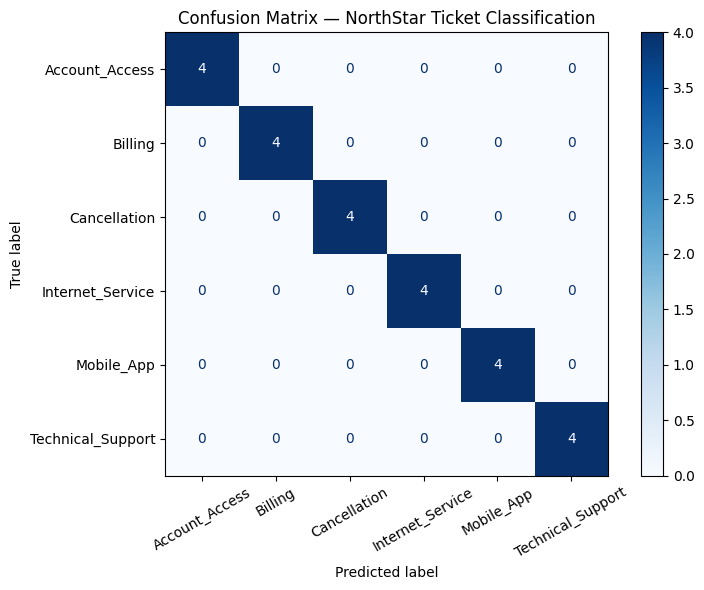

Confusion matrix saved.


In [11]:
# Confusion Matrix
categories = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=categories)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=categories)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=30)
ax.set_title('Confusion Matrix — NorthStar Ticket Classification', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('Confusion matrix saved.')

**Business Interpretation of Results:**

**Accuracy — 100% on the test set.** Every one of the 24 test tickets was correctly classified. While this is an encouraging result, it is important to be critical: a 100% accuracy on 120 synthetic, template-based tickets does not reflect real-world performance. Real customer messages contain spelling errors, abbreviations, mixed topics, and informal language that a model trained on this data would likely struggle with. This model should be treated as a proof-of-concept, not a production-ready classifier. Realistic performance on real telecom data would likely be in the range of 75–90%, depending on the quality and volume of training data.

**Classification report — perfect precision, recall, and F1 for all six categories.** Each category achieved scores of 1.00 across all metrics. This is expected for a synthetic dataset where each category uses consistent and distinctive vocabulary.

**Precision vs. Recall trade-off:** For this business use case, **recall** is the more critical metric. A missed classification (low recall) means a ticket goes unrouted or is routed to the wrong team, causing delays and frustrating the customer. A false alarm (low precision) — where the model routes a ticket to the wrong team — is also harmful but easier to detect and correct. For high-priority categories like *Billing* and *Account_Access*, where unresolved issues can lead to customer churn, maximizing recall is essential even if it means accepting slightly lower precision. In a future iteration, the threshold for each category could be tuned independently to optimize recall where it matters most.

**Confusion matrix:** All 24 test tickets fall on the diagonal — zero misclassifications on this dataset. In a real deployment, the most likely error pairs would be *Technical_Support* and *Internet_Service* (both involve connectivity-related language) or *Account_Access* and *Cancellation* (both involve account-level actions). These misroutes would add a small delay but are not severe errors.

**Bottom line for the business:** The model demonstrates that NLP-based ticket routing is feasible for NorthStar Telecom. Even with more realistic accuracy in the 80–85% range on real data, automating the routing of 80–85% of tickets would significantly reduce manual workload and response times.

---
## Task 8 — Business Interpretation

**What the model is trying to predict:**  
The model predicts the `IssueCategory` of each incoming NorthStar Telecom customer support message — classifying it as one of six categories: Billing, Internet_Service, Mobile_App, Technical_Support, Account_Access, or Cancellation.

**Dataset used:**  
NLP Dataset 2 — NorthStar Telecom Service Complaint Classification. A synthetic dataset of 120 customer support tickets collected across multiple channels (Email, Chat, Call Center, Mobile App, Web Form), with 20 tickets per category.

**Text column and target variable:**  
- Text input: `MessageText` (raw customer support message)  
- Target label: `IssueCategory` (six-class classification)

**Preprocessing steps applied:**  
Lowercase conversion → punctuation removal → tokenization → stopword removal → lemmatization → TF-IDF vectorization (unigrams + bigrams, top 500 features, fit on training data only)

**Model used:**  
Logistic Regression (trained on 80% of data, tested on 20%)

**Result obtained:**  
100% accuracy on the test set (24 tickets). All six categories achieved perfect precision, recall, and F1-score. This result is expected given the synthetic, template-based nature of the dataset and should not be interpreted as a guarantee of real-world performance.

**One business insight from the text data:**  
The exploratory word frequency analysis revealed that the dataset contains template artefacts — repeated boilerplate phrases such as "Ticket created by Alex" — that appear across all categories and carry no complaint-type signal. In a real-world deployment, identifying and removing such repeated phrases (through domain-specific stopword lists or named-entity filtering) would be a necessary preprocessing step to prevent the model from learning noise rather than meaningful patterns.

**One limitation of the model and dataset:**  
The dataset contains only 120 synthetic tickets with carefully controlled, category-specific vocabulary. Real customer support messages are far more varied — customers use slang, mix issues in one message, make spelling errors, and describe the same problem in many different ways. The model has not been exposed to this variability, so its 100% accuracy is not a realistic performance estimate. To deploy this classifier in production, NorthStar Telecom would need to collect thousands of real, labelled tickets and retrain the model on that data.

---
## Responsible AI Reflection

**Potential sources of bias:**

Although this is a complaint classification model rather than a credit or eligibility model, there are still fairness considerations worth acknowledging:

1. **Channel bias:** The training data includes tickets from five channels (Email, Chat, Call Center, Mobile App, Web Form). If certain customer segments — for example, elderly customers or those with limited digital literacy — predominantly use one channel (e.g., Call Center), and if that channel uses different language patterns, the model may perform unevenly across customer groups. A model trained mainly on typed text may not generalize well to transcribed call-center audio.

2. **Language and literacy bias:** The model was trained on well-formed English sentences. Customers who write in fragmented English, use heavy abbreviations, or mix languages may receive poorer classification accuracy, leading to slower service for those groups — which disproportionately affects non-native English speakers.

3. **City and plan-type representation:** If the training data over-represents certain cities or plan types, the model may be less accurate for customers in underrepresented regions or on less common plans.

**Human oversight requirement:**

This model should be used to *support* human agents, not to replace them. The recommended approach is a confidence-threshold system: tickets where the model's predicted probability exceeds 90% are auto-routed, while tickets with lower confidence are flagged for manual review by an agent. This ensures that ambiguous or unusual messages always receive human attention. The model's outputs should be monitored regularly for accuracy by category and by customer segment to detect drift or disparate error rates before they impact service quality.

**Data privacy:** Customer support messages may contain personally identifiable information (PII) such as names, addresses, account numbers, and payment details. Any production NLP pipeline must include PII detection and redaction before data is used for model training or retraining.